In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 12000

data = pd.DataFrame({
    "user_id": np.random.randint(1000, 2000, n),
    "session_id": np.random.randint(5000, 8000, n),
    "timestamp": pd.date_range(start="2025-01-01", periods=n, freq='min'),
    "product_id": np.random.randint(100, 200, n),
    "category": np.random.choice(["Decor", "Furniture", "Lighting"], n),
    "action": np.random.choice(["view", "cart", "purchase"], n, p=[0.6, 0.25, 0.15]),
    "session_duration": np.random.randint(30, 300, n)
})

data.to_csv("data/ecommerce_data.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
data = pd.read_csv("data/ecommerce_data.csv")


In [4]:
print(data.head())

print(data.info())

print(data.describe())

print(data.isnull().sum())

   user_id  session_id            timestamp  product_id   category action  \
0     1102        6162  2025-01-01 00:00:00         166  Furniture   cart   
1     1435        7486  2025-01-01 00:01:00         148  Furniture   view   
2     1860        5561  2025-01-01 00:02:00         149  Furniture   cart   
3     1270        7165  2025-01-01 00:03:00         157  Furniture   cart   
4     1106        6737  2025-01-01 00:04:00         152      Decor   view   

   session_duration  
0                56  
1               160  
2               156  
3                40  
4               226  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           12000 non-null  int64 
 1   session_id        12000 non-null  int64 
 2   timestamp         12000 non-null  object
 3   product_id        12000 non-null  int64 
 4   category        

In [10]:
# Total Users, Sessions & Purchases
total_users = data["user_id"].nunique()
total_sessions = data["session_id"].nunique()

total_purchases = data[data["action"] == "purchase"].shape[0]

print("Total Users:", total_users)
print("Total Sessions:", total_sessions)
print("Total Purchases:", total_purchases)

Total Users: 1000
Total Sessions: 2950
Total Purchases: 1782


In [11]:
#Action Distribution
action_counts = data["action"].value_counts()

print(action_counts)

action
view        7256
cart        2962
purchase    1782
Name: count, dtype: int64


In [12]:
#Conversion Funnel
views = data[data["action"] == "view"].shape[0]
cart = data[data["action"] == "cart"].shape[0]
purchase = data[data["action"] == "purchase"].shape[0]

print("Views:", views)
print("Cart:", cart)
print("Purchases:", purchase)

cart_rate = (cart / views) * 100
purchase_rate = (purchase / cart) * 100

print("View to Cart Rate:", round(cart_rate,2), "%")
print("Cart to Purchase Rate:", round(purchase_rate,2), "%")

Views: 7256
Cart: 2962
Purchases: 1782
View to Cart Rate: 40.82 %
Cart to Purchase Rate: 60.16 %


In [13]:
# Most Popular Category
popular_category = data["category"].value_counts()

print(popular_category)

category
Lighting     4055
Decor        4003
Furniture    3942
Name: count, dtype: int64


In [14]:
# Top Purchased Products
purchased = data[data["action"] == "purchase"]

top_products = purchased["product_id"].value_counts().head(10)

print(top_products)

product_id
139    27
124    27
170    27
106    27
162    27
153    27
114    25
158    25
121    24
177    24
Name: count, dtype: int64


In [15]:
# Average Session Duration
avg_duration = data["session_duration"].mean()

print("Average Session Duration:", round(avg_duration,2), "seconds")

Average Session Duration: 165.31 seconds


In [16]:
# Category-wise Purchase Analysis
category_purchase = data[data["action"] == "purchase"]

result = category_purchase.groupby("category").size()

print(result)

category
Decor        585
Furniture    597
Lighting     600
dtype: int64


In [17]:
# User Activity Analysis
active_users = data["user_id"].value_counts().head(10)

print(active_users)

user_id
1725    24
1928    24
1920    24
1824    23
1072    23
1282    22
1038    22
1068    21
1692    21
1821    21
Name: count, dtype: int64


In [18]:
# Hourly Traffic Analysis
data["timestamp"] = pd.to_datetime(data["timestamp"])

data["hour"] = data["timestamp"].dt.hour

hourly_traffic = data.groupby("hour").size()

print(hourly_traffic)

hour
0     540
1     540
2     540
3     540
4     540
5     540
6     540
7     540
8     480
9     480
10    480
11    480
12    480
13    480
14    480
15    480
16    480
17    480
18    480
19    480
20    480
21    480
22    480
23    480
dtype: int64


In [19]:
# Daily Purchase Trend
data["date"] = data["timestamp"].dt.date

daily_purchase = data[data["action"] == "purchase"]

trend = daily_purchase.groupby("date").size()

print(trend)

date
2025-01-01    193
2025-01-02    210
2025-01-03    217
2025-01-04    206
2025-01-05    210
2025-01-06    207
2025-01-07    221
2025-01-08    233
2025-01-09     85
dtype: int64


In [20]:
# Retention-like Analysis
repeat_users = data.groupby("user_id")["session_id"].nunique()

repeat_users = repeat_users[repeat_users > 1]

print("Repeat Users:", repeat_users.count())

Repeat Users: 1000


In [21]:
# Category Conversion Rate
views = data[data["action"] == "view"].groupby("category").size()

purchases = data[data["action"] == "purchase"].groupby("category").size()

conversion = (purchases / views) * 100

print(conversion)

category
Decor        23.867809
Furniture    25.777202
Lighting     24.106067
dtype: float64


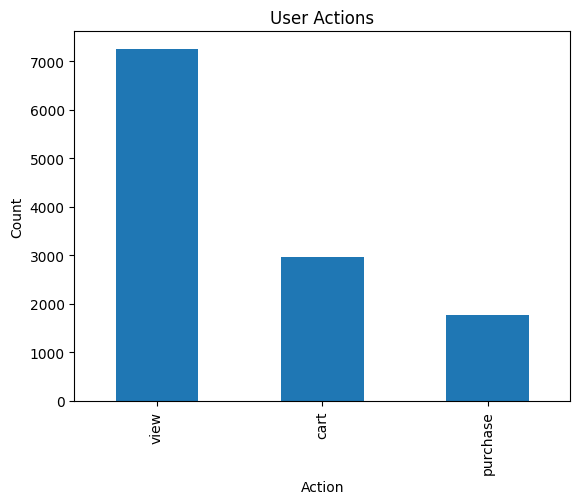

In [22]:
# Visualization — Action Distribution
import matplotlib.pyplot as plt

data["action"].value_counts().plot(kind="bar")

plt.title("User Actions")
plt.xlabel("Action")
plt.ylabel("Count")

plt.show()

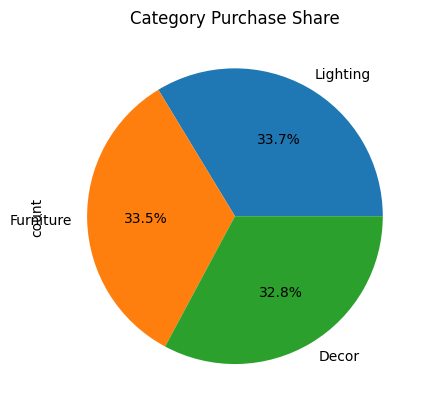

In [23]:
# Visualization — Category Sales
purchase_data = data[data["action"] == "purchase"]

purchase_data["category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Category Purchase Share")

plt.show()

In [24]:
# Advanced KPI Dashboard Metrics
total_events = len(data)

purchase_events = len(data[data["action"] == "purchase"])

conversion_rate = (purchase_events / total_events) * 100

avg_session = data["session_duration"].mean()

print("Total Events:", total_events)
print("Purchase Events:", purchase_events)
print("Conversion Rate:", round(conversion_rate,2), "%")
print("Average Session Duration:", round(avg_session,2))

Total Events: 12000
Purchase Events: 1782
Conversion Rate: 14.85 %
Average Session Duration: 165.31


In [26]:
# Save Analysis Results to TXT File
with open("analysis_report.txt", "w") as f:

    f.write("E-Commerce Analysis Report\n")
    f.write("============================\n\n")

    f.write(f"Total Users: {total_users}\n")
    f.write(f"Total Sessions: {total_sessions}\n")
    f.write(f"Total Purchases: {total_purchases}\n")
    f.write(f"Average Session Duration: {avg_duration:.2f}\n")